In [1]:
import importlib
import os
import pickle
from pathlib import Path
import re

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from behave_analysis.visualize.visualize_utils import open_tracking_data
from behave_analysis.process.session import get_experiment
from behave_analysis.utils.creating_directories import make_directory
from behave_analysis.analyze.single_trial import preprocess_regression
from behave_analysis.analyze.single_trial import single_trial_regression
from behave_analysis.analyze.single_trial.single_trial_regression import SingleTrialRegression
from behave_analysis.analyze.single_trial.preprocess_regression import PreprocessSingleTrialRegression
from behave_analysis.database.Experiments.JAL006_ex import JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_flip3_18mar, JAL6_flip7_1apr, JAL6_shelt_4mar


# Sessions to consider

In [2]:
# JAL6
experiments_objects = [JAL6_shelt_4mar, JAL6_flip3_18mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_28mar]
experiments_objects = [JAL6_shelt_4mar]

In [3]:
c_type = "good"
dir = make_directory(r"Z:\Jasmine_Laurence\single_trial_overview")
dir = Path(dir)

# Loop through sessions and generate R2 scores across all homings all conditions

In [4]:
importlib.reload(preprocess_regression)
importlib.reload(single_trial_regression)

# Lazy naming of sessions TODO - hardcode session names
session_names = ["JAL6_4th_March", "JAL6_18th_March", "JAL6_21st_March", "JAL6_25th_March", "JAL6_28th_March"]
session_names = ["JAL6_4th_March"]

for i, session in enumerate(experiments_objects):
    loaded_session = get_experiment(session)
    
    # Define paths
    video_and_spike_data_path = os.path.join(loaded_session.base_path, loaded_session.processed_path, "good_video_spike_count_df.parquet")
    homing_path = os.path.join(loaded_session.base_path, loaded_session.processed_path, "homings", "homings_obj.pkl")
    escape_path = os.path.join(loaded_session.base_path, loaded_session.processed_path, "escapes", "escapes_obj.pkl")

    # Load data
    try:
        video_df = pl.read_csv(os.path.join(loaded_session.base_path, loaded_session.processed_path) + "\\" "full_video_dataframe.csv")
        with open(homing_path, "rb") as hf:
                homings_object = pickle.load(hf)
        video_and_spike_data = pl.read_parquet(video_and_spike_data_path)
        frame_by_cluster_matrix = np.load(os.path.join(loaded_session.base_path, loaded_session.processed_path) + "\\" + "frame_by_" + c_type + "_cluster_matrix.npy")
        tracking_data = open_tracking_data(loaded_session)
        with open(escape_path, "rb") as ef:
                escape_object = pickle.load(ef)
        cluster_Ids = np.load(str(os.path.join(loaded_session.base_path, loaded_session.processed_path) + "/" + c_type + "_cluster_Ids.npy"))
    
    except FileNotFoundError:
        print("One of the files was not found")
    
    finally:
        # Check if the homing object has the expected keys
        angle_data = homings_object.homing_angles_dic
        expected_keys = ["avg_pre_flip_head_angle", "avg_post_flip_head_angle", "avg_hsa"]
        assert all(key in angle_data.keys() for key in expected_keys), "The keys are not as expected in the homing angle data, please regenerate the homing object"

    # If there is no barrier in this session hard code it based on a prior session
    if not "barrier_loc" in tracking_data.keys():
        tracking_data["barrier_loc"] = [[224, 515], [797, 512], [510, 513]]
    
    # Run analysis
    pp_single_trial_obj = PreprocessSingleTrialRegression(
        video_df=video_df,
        homings_obj=homings_object,
        video_and_spike_data=video_and_spike_data,
        frame_by_cluster_matrix=frame_by_cluster_matrix,
        save_path=dir,
        velocity_data=tracking_data["avg_Velocity"],
        similar_homings=False,
        barrier_location=tracking_data["barrier_loc"],
        shelter_location=tracking_data["shelter_loc"],
        escape_object=escape_object,
        remove_escapes=False,
        save_plots=False)
                    
    SingleTrialRegression(
        design_matrix=pp_single_trial_obj.design_matrix,
        save_path=dir,
        dependents_df=pp_single_trial_obj.targets_df,
        tracking_data=tracking_data,
        homing_list=pp_single_trial_obj.homing_list,
        spike_homing_list=pp_single_trial_obj.spike_data_per_homing,
        condition_per_homing=pp_single_trial_obj.condition_per_homing,
        cluster_ids=cluster_Ids,
        initial_directions=pp_single_trial_obj.initial_directions,
        conversion_from_left_right_to_pre_post_flip=pp_single_trial_obj.convert_left_right_to_pre_post_flip,
        session_name=session_names[i])
            

2024-08-29 13:42:14.226 | INFO     | behave_analysis.analyze.single_trial.preprocess_regression:__init__:53 - Initializing the single trial regression preprocessing object
2024-08-29 13:42:14.227 | INFO     | behave_analysis.utils.label_barrier_edges:check_which_barrier_location_is_which_orientation:15 - The barrier location pre flip is [158, 506] and post flip is [870, 511]
2024-08-29 13:42:14.227 | INFO     | behave_analysis.utils.label_barrier_edges:check_which_barrier_location_is_which_orientation:17 - The barrier preflip location is the left edge
2024-08-29 13:42:14.291 | INFO     | behave_analysis.utils.label_barrier_edges:check_which_barrier_location_is_which_orientation:15 - The barrier location pre flip is [158, 506] and post flip is [870, 511]
2024-08-29 13:42:14.292 | INFO     | behave_analysis.utils.label_barrier_edges:check_which_barrier_location_is_which_orientation:17 - The barrier preflip location is the left edge
2024-08-29 13:42:14.292 | WARNING  | behave_analysis.ana

# Load the r2s and plot

In [8]:
load_dir = r"Z:\Jasmine_Laurence\single_trial_overview\r2_scores"
# Initialize an empty list to store the extracted parts of the filenames
file_names = []
r2_data = {}

# Loop through the files in the directory
for file in os.listdir(load_dir):
    
    # Use regex to extract everything before '_r2'
    match = re.match(r'^(.*)_r2', file)
    extracted_part = None
    if match:
        extracted_part = match.group(1)
        file_names.append(extracted_part)
        
    # Load the .pickle files
    if file.endswith(".pickle"):
        with open(os.path.join(load_dir, file), "rb") as f:
            data = pickle.load(f)
            r2_data[extracted_part] = data
            
session_names = ["JAL6_4th_March", "JAL6_18th_March", "JAL6_21st_March", "JAL6_25th_March", "JAL6_28th_March"]

# Use session names to sort the dictionary
r2_data = {k: r2_data[k] for k in session_names}

# Print the extracted filenames
df = pd.DataFrame.from_dict(r2_data, orient="index")

                   frames  mouse_x_position  mouse_y_position      hdir  \
JAL6_4th_March  -0.490497         -0.650184          0.438347  0.292273   
JAL6_18th_March  0.631634          0.713480          0.819761  0.783559   
JAL6_21st_March  0.624329          0.724466          0.853149  0.782325   
JAL6_25th_March  0.722477          0.768974          0.824826  0.772560   
JAL6_28th_March  0.339161          0.728078          0.787462  0.724191   

                      hsa  h_preflipbar_a  h_postflipbar_a  homing_id  \
JAL6_4th_March   0.280772        0.456351         0.157364  -1.727961   
JAL6_18th_March  0.777217        0.800366         0.760802   0.538180   
JAL6_21st_March  0.767683        0.803757         0.771468   0.679571   
JAL6_25th_March  0.746101        0.778112         0.824181   0.642020   
JAL6_28th_March  0.727285        0.788784         0.760220   0.241317   

                 post_flip_index  pre_flip_index  velocity    random  
JAL6_4th_March         -0.072169       

In [9]:
columns_to_remove = ["random", "homing_id", "frames"]
df = df.drop(columns=columns_to_remove)

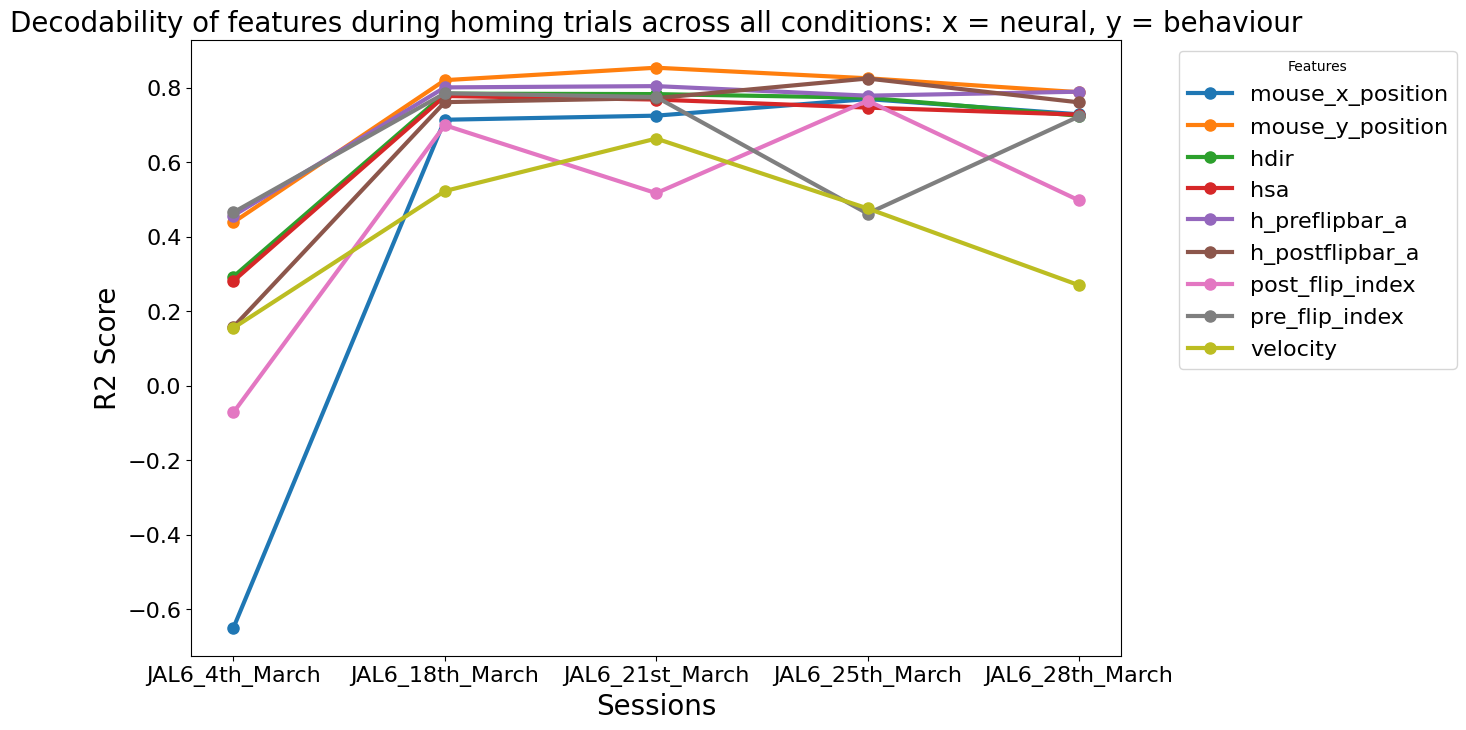

In [10]:
plt.figure(figsize=(12, 8))

# Iterate over each column (feature) and plot it
for column in df.columns:
    plt.plot(df.index, df[column], marker='o', label=column, linewidth=3, markersize=8)

# Add labels and title
plt.xlabel('Sessions', fontsize=20)
plt.ylabel('R2 Score', fontsize=20)
plt.title('Decodability of features during homing trials across all conditions: x = neural, y = behaviour', fontsize=20)

# Make font size larger and readable
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Add legend to differentiate between features
plt.legend(title="Features", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=16)

# Display the plot
plt.show()